In [ ]:
!pip install -q lightgbm imbalanced-learn scikit-plot kagglehub[pandas-datasets]

In [ ]:
import numpy as np
import pandas as pd

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/default-of-credit-card-clients-dataset",
    "UCI_Credit_Card.csv"
)

target = "default.payment.next.month"

X = df.drop(columns=["ID", target])
y = df[target]

print("Dataset Shape:", df.shape)
print()

print("Original Class Distribution")
print(y.value_counts())
print()

# Paper leakage
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("After Oversampling")
print(pd.Series(y_res).value_counts())
print()

X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

# Used for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Number of Features:", X.shape[1])

/tmp/ipykernel_1031/970502516.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Dataset Shape: (30000, 25)

Original Class Distribution
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

After Oversampling
default.payment.next.month
1    23364
0    23364
Name: count, dtype: int64

Train Shape: (35046, 23)
Test Shape: (11682, 23)
Number of Features: 23


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    average_precision_score
)

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Random Forest":
        RandomForestClassifier(random_state=42, n_estimators=1),

    "Naive Bayes":
        GaussianNB(),

    "LGBM":
        LGBMClassifier(random_state=42, verbose=-1),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Gradient Boost":
        GradientBoostingClassifier(random_state=42),

    "LDA":
        LinearDiscriminantAnalysis(),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=500,
            random_state=42
        )
}

results = []
trained = {}

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "LDA", "MLP"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]

    trained[name] = model

    results.append([
        name,
        precision_score(y_test,preds),
        recall_score(y_test,preds),
        f1_score(y_test,preds),
        accuracy_score(y_test,preds),
        average_precision_score(y_test,probs)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Precision",
        "Recall",
        "F1",
        "Accuracy",
        "PR_AUC"
    ]
)

results_df.sort_values("F1",ascending=False)

,Algorithm,Precision,Recall,F1,Accuracy,PR_AUC
1,Decision Tree,0.820289,0.959918,0.884627,0.874337,0.807634
3,Random Forest,0.770314,0.895787,0.828326,0.813645,0.742381
2,KNN,0.710817,0.823810,0.763154,0.743366,0.771979
5,LGBM,0.780067,0.710217,0.743505,0.754066,0.834204
9,MLP,0.726066,0.746376,0.736081,0.731382,0.802966
7,Gradient Boost,0.766491,0.646086,0.701157,0.723592,0.800088
4,Naive Bayes,0.526905,0.938598,0.674925,0.546225,0.694045
6,AdaBoost,0.771826,0.577520,0.660683,0.702277,0.777932
0,Logistic Regression,0.681502,0.634658,0.657246,0.667779,0.749181
8,LDA,0.689414,0.622037,0.653994,0.669663,0.747759


In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve

def threshold_plot(model,X,y,title):

    probs = model.predict_proba(X)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y,
        probs
    )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-10)
    )

    queue_rate = [
        np.mean(probs >= t)
        for t in thresholds
    ]

    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx]

    plt.figure(figsize=(10,6))

    plt.plot(thresholds,precision,label="Precision")
    plt.plot(thresholds,recall,label="Recall")
    plt.plot(thresholds,f1,label="F1 Score")
    plt.plot(thresholds,queue_rate,label="Queue Rate")

    plt.axvline(
        best_thresh,
        linestyle="--"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.show()

    print("Best Threshold:",round(best_thresh,4))
    print("Best F1:",round(f1[best_idx],4))

    return best_thresh

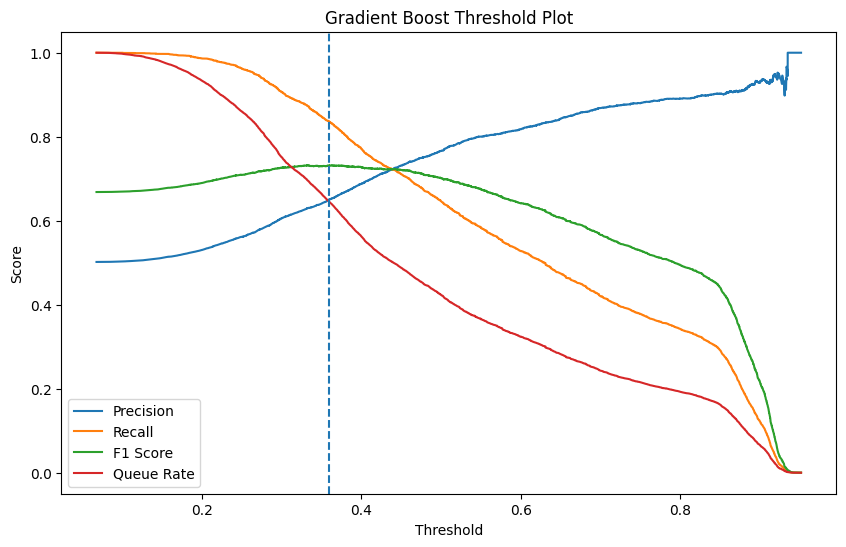

Best Threshold: 0.3593
Best F1: 0.732


In [ ]:
gb = trained["Gradient Boost"]

gb_thresh = threshold_plot(
    gb,
    X_test,
    y_test,
    "Gradient Boost Threshold Plot"
)

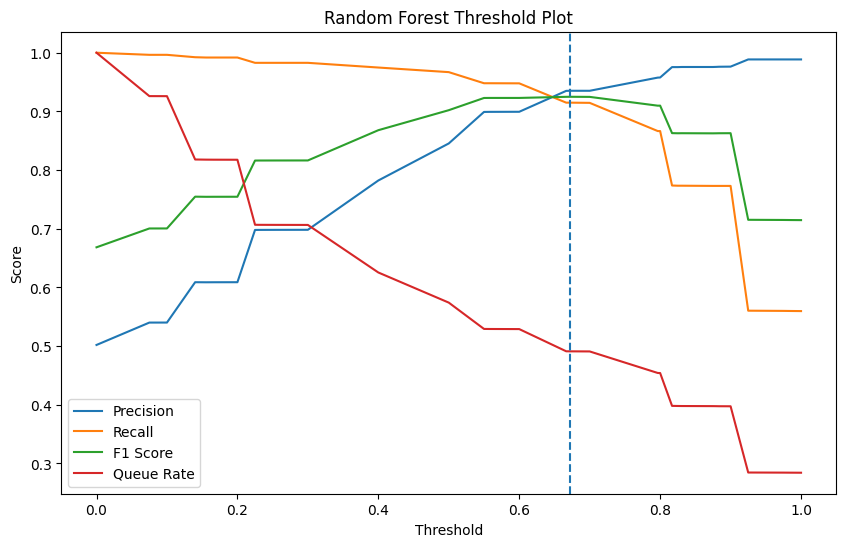

Best Threshold: 0.6716
Best F1: 0.9249


In [ ]:
rf = trained["Random Forest"]

rf_thresh = threshold_plot(
    rf,
    X_test,
    y_test,
    "Random Forest Threshold Plot"
)

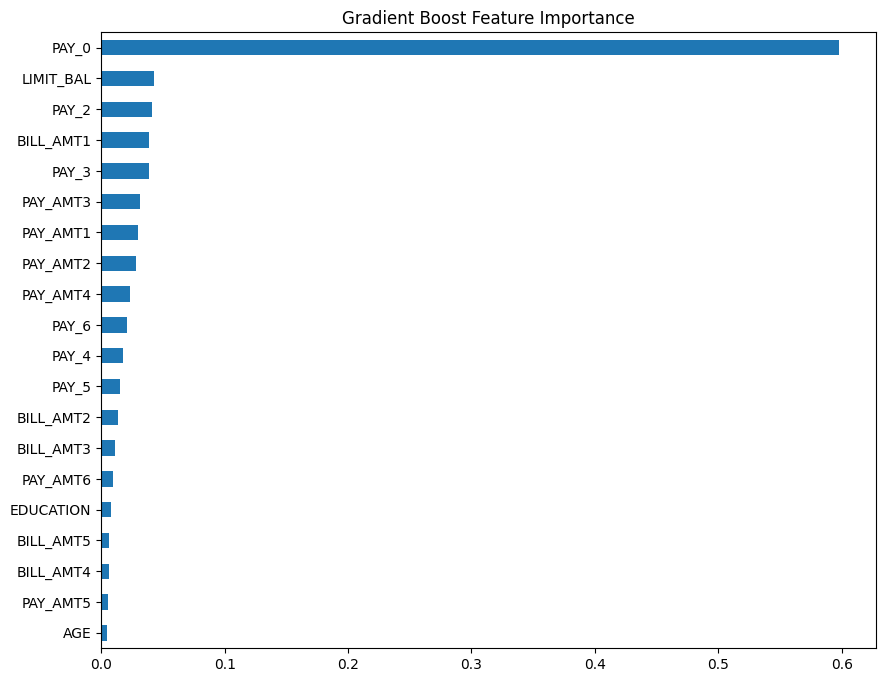

,0
PAY_0,0.598023
LIMIT_BAL,0.042507
PAY_2,0.041480
BILL_AMT1,0.038849
PAY_3,0.038712
PAY_AMT3,0.031445
PAY_AMT1,0.029731
PAY_AMT2,0.028311
PAY_AMT4,0.023214
PAY_6,0.020636


In [ ]:
imp = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,8))
imp.tail(20).plot(kind="barh")
plt.title("Gradient Boost Feature Importance")
plt.show()

imp.sort_values(ascending=False).head(20)

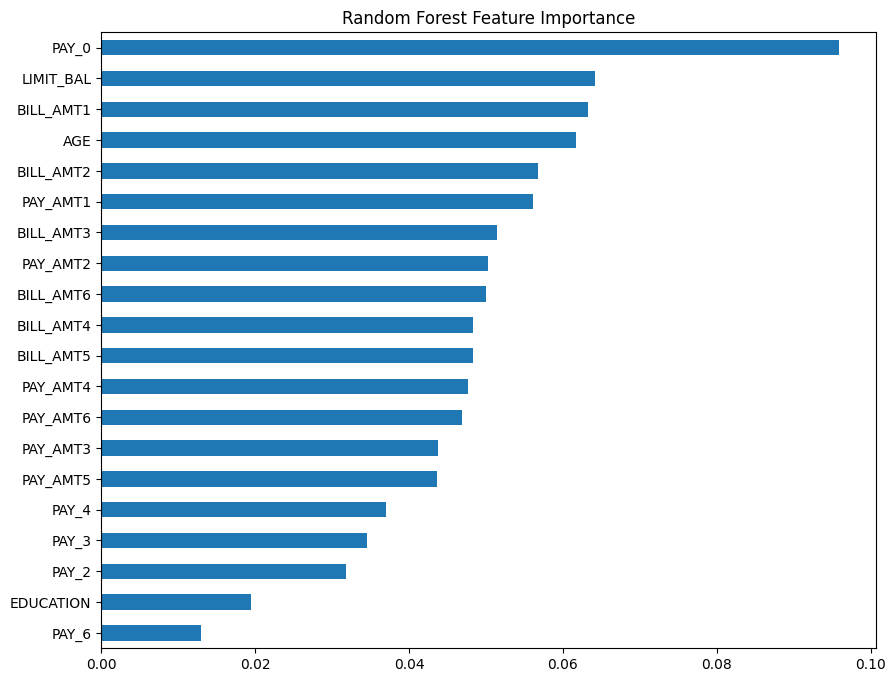

,0
PAY_0,0.095910
LIMIT_BAL,0.064173
BILL_AMT1,0.063293
AGE,0.061708
BILL_AMT2,0.056726
PAY_AMT1,0.056112
BILL_AMT3,0.051421
PAY_AMT2,0.050217
BILL_AMT6,0.049974
BILL_AMT4,0.048360


In [ ]:
imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10,8))
imp.tail(20).plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

imp.sort_values(ascending=False).head(20)

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,None]
}

gb_grid = {
    "n_estimators":[100,200],
    "learning_rate":[0.05,0.1],
    "max_depth":[3,5]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_train,y_train)
gb_search.fit(X_train,y_train)

print(rf_search.best_params_)
print(gb_search.best_params_)

{'max_depth': None, 'n_estimators': 300}
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
print(y_train.value_counts(normalize=True))
print()
print(y_test.value_counts(normalize=True))

default.payment.next.month
0    0.500628
1    0.499372
Name: proportion, dtype: float64

default.payment.next.month
1    0.501883
0    0.498117
Name: proportion, dtype: float64
